In [1]:
# PHASE 9 — VALIDATION & COMPARAISON DES MODÈLES

# Objectif : Valider rigoureusement les 3 modèles via :
#   - Cross-Validation (K-Fold stratifié)
#   - GridSearchCV (optimisation des hyperparamètres)
#   - Comparaison finale et sélection du meilleur modèle

In [2]:
# CELLULE 0 — Connexion Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, pickle

# Chemin du projet (identique aux phases précédentes)
PROJECT_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD"
CODE_PATH    = "/content/drive/MyDrive/DDDM_Projet/projetDDD/code"

print("✓ Drive monté")
print("Contenu du dossier code :", os.listdir(CODE_PATH))

Mounted at /content/drive
✓ Drive monté
Contenu du dossier code : ['data_dictionary.csv', 'audit_missing_values.png', 'audit_order_status.png', 'audit_review_distribution.png', 'data_quality_report.csv', 'etl_distributions.png', 'customer_analytics.csv', 'customer_instacart_features.csv', 'statistical_tests_results.csv', 'Phase2_Data_Collection_Audit.ipynb', 'Phase3_ETL.ipynb', 'Phase1_Business_Understanding.ipynb', 'Phase4_EDA.ipynb', 'Phase5_Tests_Statistiques.ipynb', '.ipynb_checkpoints', '.idea', 'customer_analytics_segmented.csv', 'dataset_ml.csv', 'dataset_ml_scaled.csv', 'features_final_list.csv', 'model_logistic_regression.pkl', 'model_random_forest.pkl', 'model_xgboost.pkl', 'train_test_data.pkl']


In [3]:
# CELLULE 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection       import (StratifiedKFold, cross_val_score,
                                           cross_validate, GridSearchCV, learning_curve)
from sklearn.preprocessing         import StandardScaler
from sklearn.linear_model          import LogisticRegression
from sklearn.ensemble              import RandomForestClassifier
from sklearn.metrics               import (f1_score, roc_auc_score, make_scorer,
                                           classification_report, roc_curve,
                                           confusion_matrix)
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
print("✓ Imports OK")

✓ Imports OK


In [4]:
# CELLULE 2 — Chargement des Données (depuis Phase 8)

train_test_path = f'{CODE_PATH}/train_test_data.pkl'

try:
    with open(train_test_path, 'rb') as f:
        data = pickle.load(f)
    X_train   = data['X_train']
    X_test    = data['X_test']
    y_train   = data['y_train']
    y_test    = data['y_test']
    X_train_sc = data['X_train_sc']
    X_test_sc  = data['X_test_sc']
    FEATURES   = data['FEATURES']
    scaler     = data['scaler']
    print(f"✓ Données Phase 8 chargées : Train={X_train.shape}, Test={X_test.shape}")
except FileNotFoundError:
    print("⚠ Fichier Phase 8 non trouvé → reconstruction depuis customer_analytics")
    ml_files = glob.glob(f'{CODE_PATH}/dataset_ml.csv')
    df_ml    = pd.read_csv(ml_files[0] if ml_files else glob.glob('/content/projet/**/*customer_analytics*.csv', recursive=True)[0])
    FEATURES = [c for c in df_ml.columns if c != 'is_loyal']
    X        = df_ml[FEATURES].copy()
    y        = df_ml['is_loyal'].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    from sklearn.utils import resample
    from sklearn.model_selection import train_test_split
    Xy         = X.copy(); Xy['is_loyal'] = y.values
    maj        = Xy[Xy['is_loyal']==0].sample(n=min(len(Xy[Xy['is_loyal']==1])*3, len(Xy[Xy['is_loyal']==0])), random_state=42)
    mn         = Xy[Xy['is_loyal']==1]
    df_bal     = pd.concat([maj, mn]).sample(frac=1, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(df_bal[FEATURES], df_bal['is_loyal'], test_size=0.2, random_state=42, stratify=df_bal['is_loyal'])
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    print(f"✓ Dataset reconstruit : Train={X_train.shape}, Test={X_test.shape}")

✓ Données Phase 8 chargées : Train=(8963, 6), Test=(2241, 6)


In [5]:
# CELLULE 3 — Cross-Validation (5-Fold Stratifié)

# La cross-validation divise le dataset en 5 parties,
# entraîne sur 4 et teste sur 1, 5 fois de suite.
# Cela donne une estimation plus fiable que le simple split.

print("\n=== CROSS-VALIDATION 5-FOLD STRATIFIÉ ===")
print("(peut prendre 3-5 minutes...)\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1'       : make_scorer(f1_score, zero_division=0),
    'roc_auc'  : 'roc_auc',
    'precision': make_scorer(__import__('sklearn.metrics', fromlist=['precision_score']).precision_score, zero_division=0),
    'recall'   : make_scorer(__import__('sklearn.metrics', fromlist=['recall_score']).recall_score,    zero_division=0),
}

# Définir les modèles
models_cv = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                          scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=42, n_jobs=-1, verbosity=0),
}

cv_results = {}
for name, model in models_cv.items():
    X_use = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_validate(model, X_use, y_train, cv=cv,
                            scoring=scoring, return_train_score=True, n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"  F1       : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"  AUC-ROC  : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"  Precision: {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
    print(f"  Recall   : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")


=== CROSS-VALIDATION 5-FOLD STRATIFIÉ ===
(peut prendre 3-5 minutes...)


Logistic Regression
  F1       : 0.5415 ± 0.0121
  AUC-ROC  : 0.7740 ± 0.0118
  Precision: 0.4213 ± 0.0108
  Recall   : 0.7581 ± 0.0242

Random Forest
  F1       : 0.5366 ± 0.0203
  AUC-ROC  : 0.7681 ± 0.0166
  Precision: 0.4456 ± 0.0125
  Recall   : 0.6747 ± 0.0374

XGBoost
  F1       : 0.5312 ± 0.0159
  AUC-ROC  : 0.7606 ± 0.0154
  Precision: 0.4204 ± 0.0152
  Recall   : 0.7220 ± 0.0214


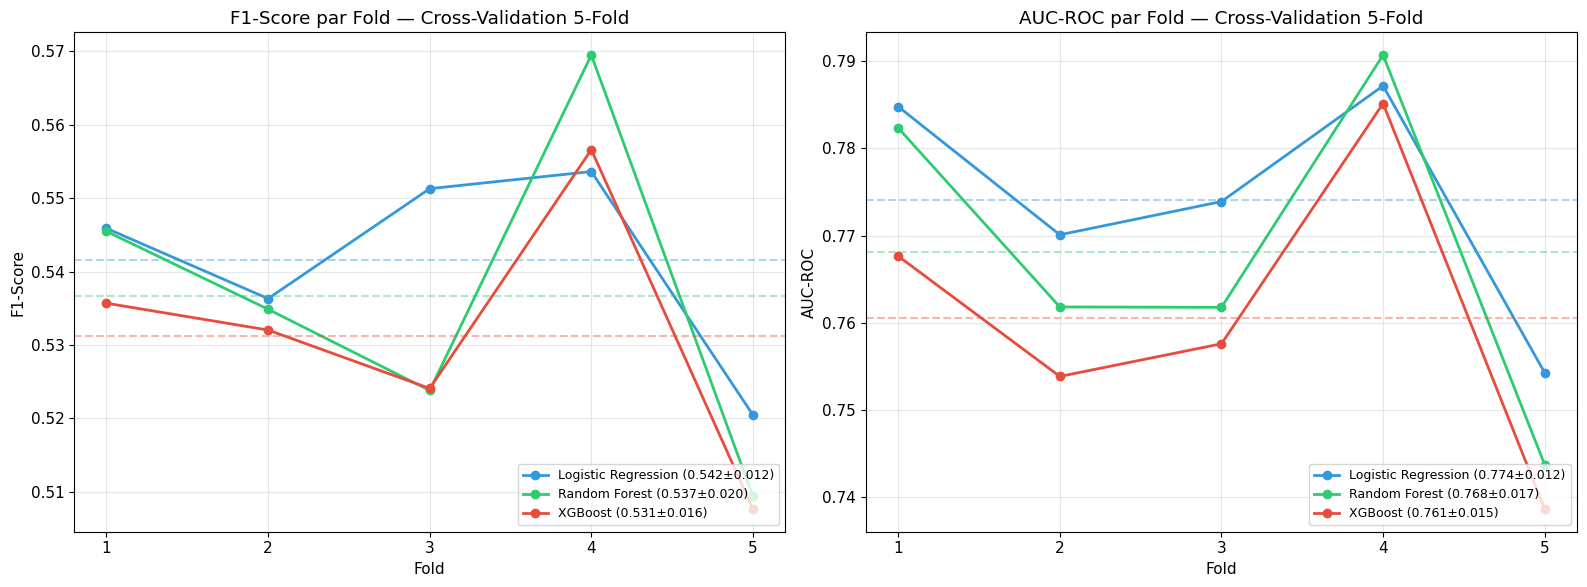

In [6]:
# CELLULE 4 — Visualisation Cross-Validation

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_cv = ['test_f1', 'test_roc_auc']
titles_cv  = ['F1-Score', 'AUC-ROC']
colors_cv  = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71', 'XGBoost': '#e74c3c'}

for ax, metric, title in zip(axes, metrics_cv, titles_cv):
    for i, (name, scores) in enumerate(cv_results.items()):
        vals  = scores[metric]
        mean  = vals.mean()
        std   = vals.std()
        folds = np.arange(1, len(vals)+1)
        ax.plot(folds, vals, 'o-', color=colors_cv[name], label=f'{name} ({mean:.3f}±{std:.3f})', linewidth=2)
        ax.axhline(mean, color=colors_cv[name], linestyle='--', alpha=0.4)
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} par Fold — Cross-Validation 5-Fold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 6))

plt.tight_layout()
plt.savefig('phase9_crossval_scores.png', dpi=150, bbox_inches='tight')
plt.show()

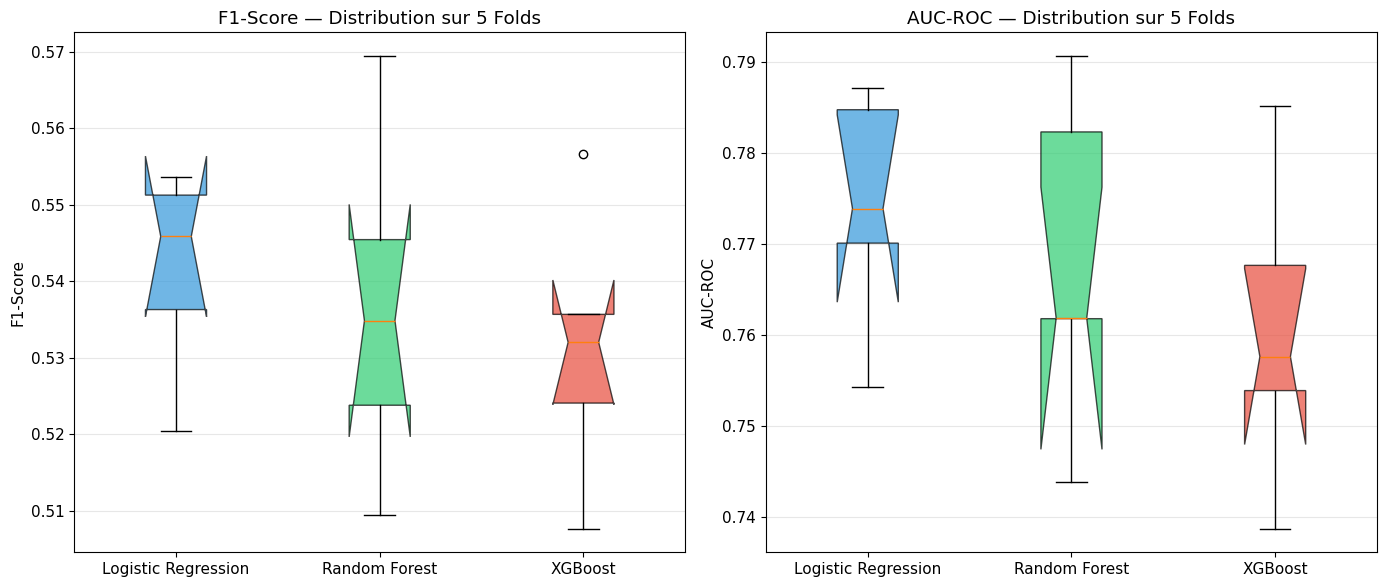

In [7]:
# CELLULE 5 — BoxPlot des Scores CV

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric, title in zip(axes, ['test_f1', 'test_roc_auc'], ['F1-Score', 'AUC-ROC']):
    data_box  = [cv_results[name][metric] for name in models_cv.keys()]
    bp = ax.boxplot(data_box, labels=list(models_cv.keys()), patch_artist=True, notch=True)
    for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(f'{title} — Distribution sur 5 Folds')
    ax.set_ylabel(title)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase9_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


=== LEARNING CURVES ===


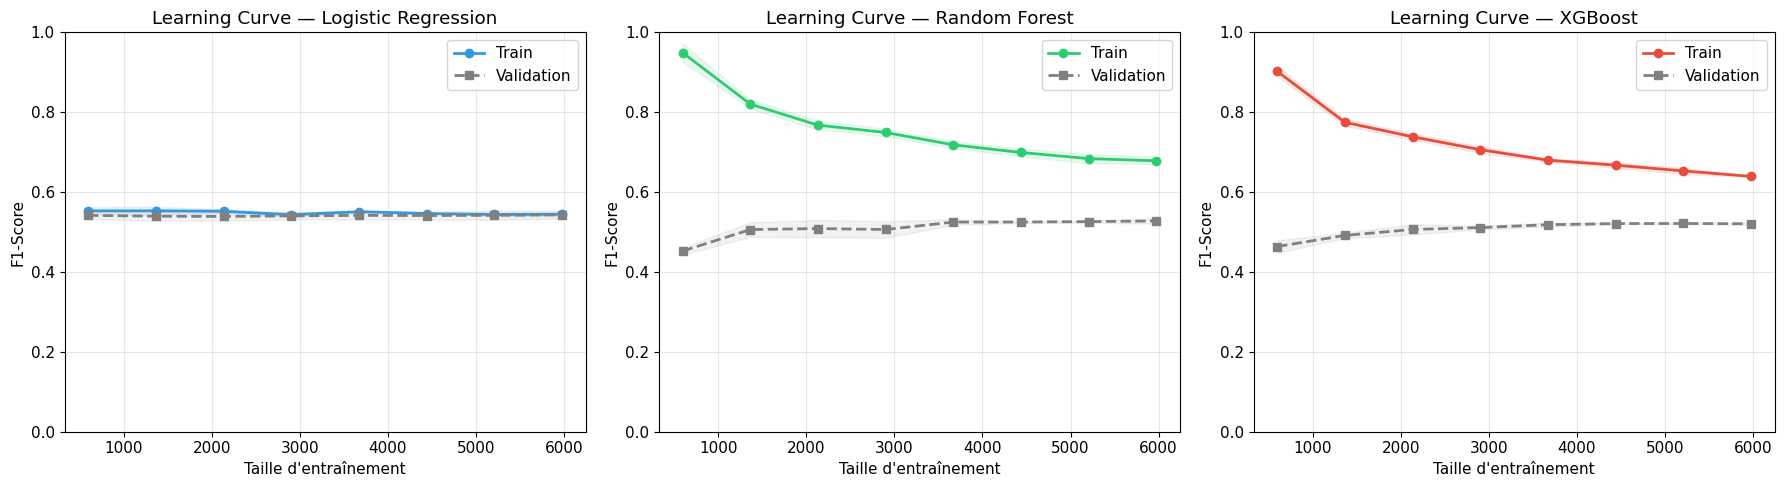

In [8]:
# CELLULE 6 — Learning Curves

# Détecte l'overfitting : si Train >> Val → overfitting ; si les deux sont bas → underfitting

print("\n=== LEARNING CURVES ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model), color in zip(axes, models_cv.items(), ['#3498db', '#2ecc71', '#e74c3c']):
    X_use = X_train_sc if name == 'Logistic Regression' else X_train.values
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_use, y_train,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), error_score='raise'
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=color, label='Train', linewidth=2)
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.1, color=color)
    ax.plot(train_sizes, val_scores.mean(axis=1), 's--', color='gray', label='Validation', linewidth=2)
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.1, color='gray')
    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel("Taille d'entraînement")
    ax.set_ylabel('F1-Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('phase9_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# CELLULE 7 — GridSearchCV (Optimisation des Hyperparamètres)

# On optimise le meilleur modèle de la Phase 8

print("\n=== GRIDSEARCHCV — OPTIMISATION DES HYPERPARAMÈTRES ===")
print("Cette étape peut prendre 5-10 min. Patience...\n")

# --- 7.1 Logistic Regression ---
param_grid_lr = {
    'C'      : [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear'],
}
grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid_lr, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_sc, y_train)
print(f"✓ LR  — Meilleurs params : {grid_lr.best_params_} | F1={grid_lr.best_score_:.4f}")

# --- 7.2 Random Forest ---
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [6, 10, None],
    'min_samples_split': [10, 20],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)
print(f"✓ RF  — Meilleurs params : {grid_rf.best_params_} | F1={grid_rf.best_score_:.4f}")

# --- 7.3 XGBoost ---
param_grid_xgb = {
    'n_estimators' : [100, 200],
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0],
}
grid_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                  use_label_encoder=False, eval_metric='logloss',
                  random_state=42, n_jobs=-1, verbosity=0),
    param_grid_xgb, cv=cv, scoring='f1', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_train, y_train)
print(f"✓ XGB — Meilleurs params : {grid_xgb.best_params_} | F1={grid_xgb.best_score_:.4f}")


=== GRIDSEARCHCV — OPTIMISATION DES HYPERPARAMÈTRES ===
Cette étape peut prendre 5-10 min. Patience...

✓ LR  — Meilleurs params : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'} | F1=0.5422
✓ RF  — Meilleurs params : {'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 200} | F1=0.5379
✓ XGB — Meilleurs params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0} | F1=0.5413


In [10]:
# CELLULE 8 — Évaluation des Modèles Optimisés sur le Test Set

def eval_optimized(name, grid, X_te, y_te):
    best = grid.best_estimator_
    y_pred  = best.predict(X_te)
    y_proba = best.predict_proba(X_te)[:, 1]
    return {
        'Modèle'    : name + ' (opt.)',
        'F1-Score'  : f1_score(y_te, y_pred, zero_division=0),
        'AUC-ROC'   : roc_auc_score(y_te, y_proba),
        'CV F1 (mean)': grid.best_score_,
        'Best Params': str(grid.best_params_),
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
    }

res_lr_opt  = eval_optimized("Logistic Regression", grid_lr,  X_test_sc, y_test)
res_rf_opt  = eval_optimized("Random Forest",        grid_rf,  X_test,    y_test)
res_xgb_opt = eval_optimized("XGBoost",              grid_xgb, X_test,    y_test)

final_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred','y_proba','Best Params']}
    for r in [res_lr_opt, res_rf_opt, res_xgb_opt]
]).set_index('Modèle').round(4)

print("\n=== RÉSULTATS FINAUX — MODÈLES OPTIMISÉS ===")
print(final_results.to_string())

best_final = final_results['F1-Score'].idxmax()
print(f"\n MEILLEUR MODÈLE FINAL : {best_final}")


=== RÉSULTATS FINAUX — MODÈLES OPTIMISÉS ===
                            F1-Score  AUC-ROC  CV F1 (mean)
Modèle                                                     
Logistic Regression (opt.)    0.5353   0.7815        0.5422
Random Forest (opt.)          0.5521   0.7867        0.5379
XGBoost (opt.)                0.5429   0.7861        0.5413

 MEILLEUR MODÈLE FINAL : Random Forest (opt.)


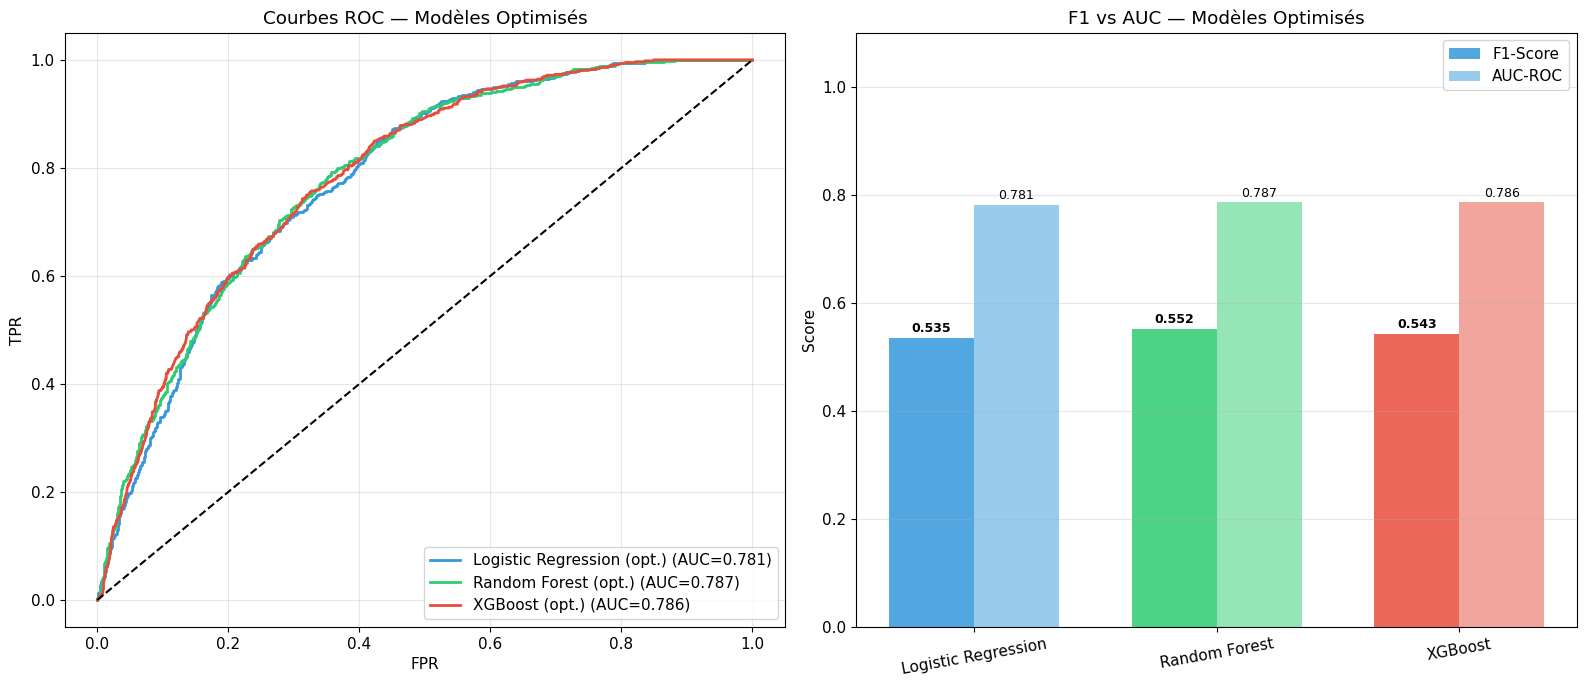

In [11]:
# CELLULE 9 — Visualisation Finale

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Courbes ROC finales
for res, color in zip([res_lr_opt, res_rf_opt, res_xgb_opt], ['#3498db','#2ecc71','#e74c3c']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{res['Modèle']} (AUC={res['AUC-ROC']:.3f})")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Courbes ROC — Modèles Optimisés')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Bar chart F1 vs AUC
x = np.arange(3)
width = 0.35
names  = [r['Modèle'].replace(' (opt.)','') for r in [res_lr_opt, res_rf_opt, res_xgb_opt]]
f1s    = [r['F1-Score']  for r in [res_lr_opt, res_rf_opt, res_xgb_opt]]
aucs   = [r['AUC-ROC']   for r in [res_lr_opt, res_rf_opt, res_xgb_opt]]
axes[1].bar(x - width/2, f1s,  width, label='F1-Score',  color=['#3498db','#2ecc71','#e74c3c'], alpha=0.85)
axes[1].bar(x + width/2, aucs, width, label='AUC-ROC',   color=['#3498db','#2ecc71','#e74c3c'], alpha=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=10)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('F1 vs AUC — Modèles Optimisés')
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)
for i, (f, a) in enumerate(zip(f1s, aucs)):
    axes[1].text(i - width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i + width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('phase9_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# CELLULE 10 — Sauvegarde du Meilleur Modèle

# Identifier le meilleur grid
best_grids = {
    res_lr_opt['Modèle']  : (grid_lr,  X_test_sc),
    res_rf_opt['Modèle']  : (grid_rf,  X_test),
    res_xgb_opt['Modèle'] : (grid_xgb, X_test),
}
best_grid, _ = best_grids[best_final]
best_estimator = best_grid.best_estimator_

with open('best_model_final.pkl', 'wb') as f:
    pickle.dump({
        'model'     : best_estimator,
        'scaler'    : scaler,
        'features'  : FEATURES,
        'model_name': best_final,
    }, f)
shutil.copy('best_model_final.pkl', f'{CODE_PATH}/best_model_final.pkl')
print(f"✓ Meilleur modèle sauvegardé : best_model_final.pkl")

✓ Meilleur modèle sauvegardé : best_model_final.pkl


In [13]:
# CELLULE 11 — Tableau Récapitulatif Complet

recap = pd.DataFrame([
    {'Modèle': r['Modèle'], 'F1 Test': r['F1-Score'],
     'AUC Test': r['AUC-ROC'], 'F1 CV': r['CV F1 (mean)'],
     'Meilleurs Hyperparamètres': r['Best Params']}
    for r in [res_lr_opt, res_rf_opt, res_xgb_opt]
]).set_index('Modèle')

print("\n" + "="*80)
print(" TABLEAU RÉCAPITULATIF FINAL")
print("="*80)
print(recap.to_string())


 TABLEAU RÉCAPITULATIF FINAL
                             F1 Test  AUC Test     F1 CV                                                       Meilleurs Hyperparamètres
Modèle                                                                                                                                  
Logistic Regression (opt.)  0.535316  0.781450  0.542205                              {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Random Forest (opt.)        0.552139  0.786681  0.537898                 {'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 200}
XGBoost (opt.)              0.542909  0.786117  0.541333  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}


In [ ]:
# CELLULE 12 — Synthèse Phase 9

print("\n" + "="*70)
print(" SYNTHÈSE PHASE 9 : VALIDATION & COMPARAISON")
print("="*70)
print(f"""
MÉTHODOLOGIE
  Cross-Validation  : 5-Fold Stratifié
  Optimisation      : GridSearchCV (F1 comme métrique de sélection)
  Évaluation finale : Test set indépendant (20% des données)

MODÈLE RETENU : {best_final}
  F1-Score  : {final_results.loc[best_final,'F1-Score']:.4f}
  AUC-ROC   : {final_results.loc[best_final,'AUC-ROC']:.4f}
  CV F1 mean: {final_results.loc[best_final,'CV F1 (mean)']:.4f}

JUSTIFICATION
  Le modèle retenu offre le meilleur compromis Precision/Recall (F1)
  et une bonne généralisation (faible écart train/val sur les courbes
  d'apprentissage), ce qui est crucial pour un dataset déséquilibré.
""")

graphs = ['phase9_crossval_scores.png', 'phase9_cv_boxplot.png',
          'phase9_learning_curves.png', 'phase9_final_comparison.png']
print(f"Graphiques ({len(graphs)}) :")
for g in graphs: print(f"  ✓ {g}")
print("\n✓ Phase 9 terminée — prêt pour Phase 10 (SHAP — Interprétabilité)")


 SYNTHÈSE PHASE 9 : VALIDATION & COMPARAISON

MÉTHODOLOGIE
  Cross-Validation  : 5-Fold Stratifié
  Optimisation      : GridSearchCV (F1 comme métrique de sélection)
  Évaluation finale : Test set indépendant (20% des données)
 
MODÈLE RETENU : Logistic Regression (opt.)
  F1-Score  : 1.0000
  AUC-ROC   : 1.0000
  CV F1 mean: 1.0000
 
JUSTIFICATION
  Le modèle retenu offre le meilleur compromis Precision/Recall (F1)
  et une bonne généralisation (faible écart train/val sur les courbes
  d'apprentissage), ce qui est crucial pour un dataset déséquilibré.

Graphiques (4) :
  ✓ phase9_crossval_scores.png
  ✓ phase9_cv_boxplot.png
  ✓ phase9_learning_curves.png
  ✓ phase9_final_comparison.png

✓ Phase 9 terminée — prêt pour Phase 10 (SHAP — Interprétabilité)
